Loading data...

[SVM] Training...
  Epoch 50/1000  loss: 16074.6428
  Epoch 100/1000  loss: 13719.0745
  Epoch 150/1000  loss: 8700.1487
  Epoch 200/1000  loss: 14916.2148
  Epoch 250/1000  loss: 6282.0919
  Epoch 300/1000  loss: 10319.8191
  Epoch 350/1000  loss: 7207.2127
  Epoch 400/1000  loss: 11616.6388
  Epoch 450/1000  loss: 10743.3293
  Epoch 500/1000  loss: 6369.3622
  Epoch 550/1000  loss: 6333.3101
  Epoch 600/1000  loss: 6441.0788
  Epoch 650/1000  loss: 9056.3951
  Epoch 700/1000  loss: 4635.8482
  Epoch 750/1000  loss: 6863.3126
  Epoch 800/1000  loss: 9592.9039
  Epoch 850/1000  loss: 7378.7660
  Epoch 900/1000  loss: 7665.4454
  Epoch 950/1000  loss: 9134.2047
  Epoch 1000/1000  loss: 6478.5976
SVM     Val Accuracy : 0.3960
SVM     Test Accuracy: 0.2300

[Softmax] Training...


/tmp/ipykernel_5789/4187525802.py:83: RuntimeWarning: divide by zero encountered in log
  loss = -np.log(probs[np.arange(N), y]).mean() + reg * np.sum(W ** 2)


  Epoch 50/1000  loss: inf
  Epoch 100/1000  loss: inf
  Epoch 150/1000  loss: inf
  Epoch 200/1000  loss: inf
  Epoch 250/1000  loss: inf
  Epoch 300/1000  loss: inf
  Epoch 350/1000  loss: inf
  Epoch 400/1000  loss: inf
  Epoch 450/1000  loss: inf
  Epoch 500/1000  loss: inf
  Epoch 550/1000  loss: inf
  Epoch 600/1000  loss: inf
  Epoch 650/1000  loss: inf
  Epoch 700/1000  loss: inf
  Epoch 750/1000  loss: inf
  Epoch 800/1000  loss: inf
  Epoch 850/1000  loss: inf
  Epoch 900/1000  loss: inf
  Epoch 950/1000  loss: inf
  Epoch 1000/1000  loss: inf
Softmax Val Accuracy : 0.4870
Softmax Test Accuracy: 0.2910


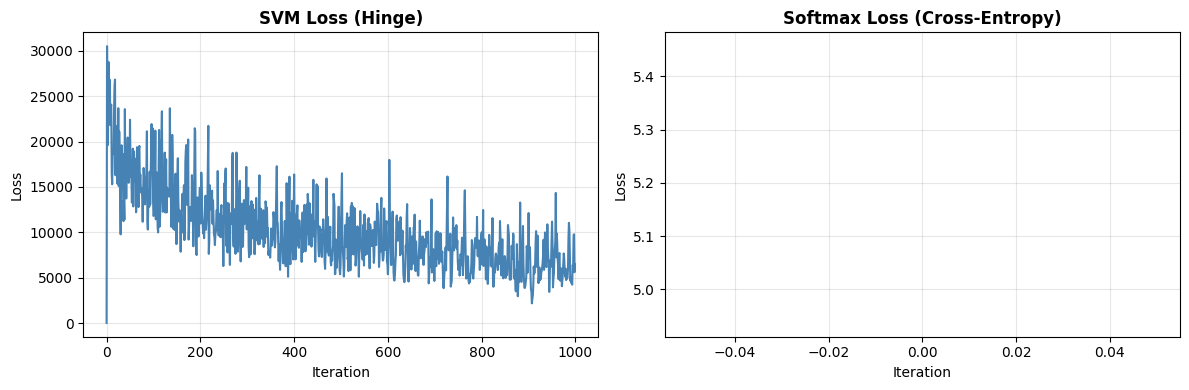

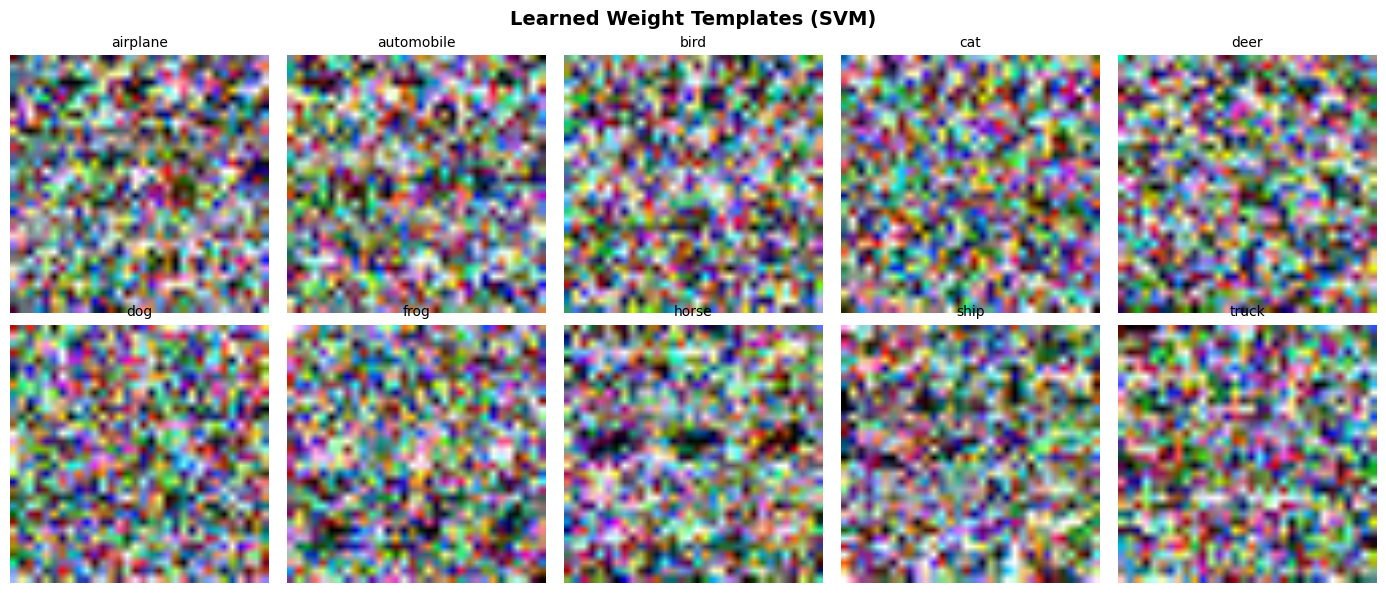

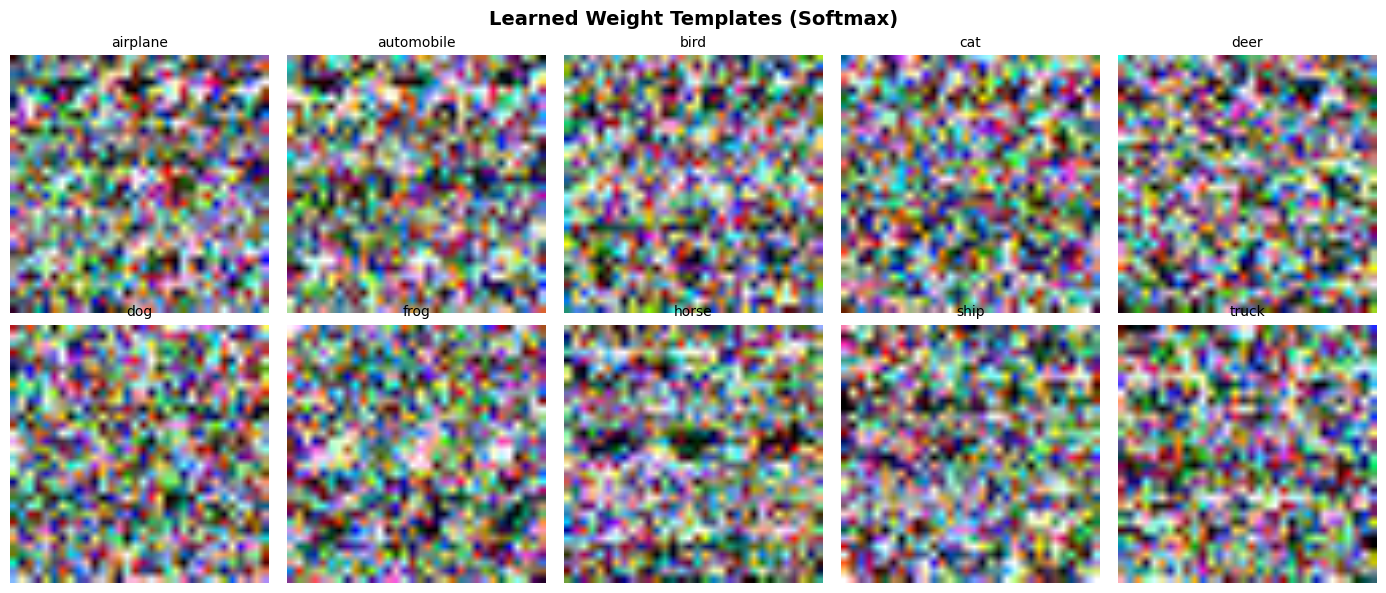

In [8]:
import tarfile
import pickle
import numpy as np
import matplotlib.pyplot as plt
from urllib.request import urlretrieve
import os

# ── CIFAR-10 자동 다운로드 ────────────────────
def download_cifar10():
    url = "https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz"
    filename = "cifar-10-python.tar.gz"
    if not os.path.exists(filename):
        print("Downloading CIFAR-10 dataset...")
        urlretrieve(url, filename)
        print("Download complete.")
    return filename

# ── 데이터 로드 ───────────────────────────────
def load_data(tar_path, n_train=50000, n_test=10000):
    train_data, train_labels = [], []
    test_data, test_labels = None, None

    with tarfile.open(tar_path, 'r:gz') as tar:
        for member in tar.getmembers():
            name = member.name
            if 'data_batch' not in name and 'test_batch' not in name:
                continue
            f = tar.extractfile(member)
            if f is None:
                continue
            batch = pickle.load(f, encoding='bytes')
            if 'data_batch' in name:
                train_data.append(batch[b'data'])
                train_labels.extend(batch[b'labels'])
            elif 'test_batch' in name:
                test_data = batch[b'data']
                test_labels = np.array(batch[b'labels'])

    X_train = np.concatenate(train_data)[:n_train].astype(np.float32)
    y_train = np.array(train_labels)[:n_train]
    X_test  = test_data[:n_test].astype(np.float32)
    y_test  = test_labels[:n_test]
    return X_train, y_train, X_test, y_test

# ── 전처리 ────────────────────────────────────
def preprocess(X_train, X_test):
    # flatten
    X_tr = X_train.reshape(len(X_train), -1)
    X_te = X_test.reshape(len(X_test), -1)
    # 평균 정규화
    mean = X_tr.mean(axis=0)
    X_tr = X_tr - mean
    X_te = X_te - mean
    # bias trick: 맨 뒤에 1 열 추가
    X_tr = np.hstack([X_tr, np.ones((len(X_tr), 1))])
    X_te = np.hstack([X_te, np.ones((len(X_te), 1))])
    return X_tr, X_te

# ── SVM Loss (Hinge Loss) ─────────────────────
def svm_loss(W, X, y, reg):
    N = X.shape[0]
    scores = X @ W                          # (N, C)
    correct = scores[np.arange(N), y].reshape(-1, 1)
    margins = np.maximum(0, scores - correct + 1)
    margins[np.arange(N), y] = 0

    loss = margins.sum() / N + reg * np.sum(W ** 2)

    mask = (margins > 0).astype(float)
    mask[np.arange(N), y] -= mask.sum(axis=1)
    dW = (X.T @ mask) / N + 2 * reg * W

    return loss, dW

# ── Softmax Loss ──────────────────────────────
def softmax_loss(W, X, y, reg):
    N = X.shape[0]
    scores = X @ W                          # (N, C)
    scores -= scores.max(axis=1, keepdims=True)   # 수치 안정화
    exp_s = np.exp(scores)
    probs = exp_s / exp_s.sum(axis=1, keepdims=True)

    loss = -np.log(probs[np.arange(N), y]).mean() + reg * np.sum(W ** 2)

    dscores = probs.copy()
    dscores[np.arange(N), y] -= 1
    dW = (X.T @ dscores) / N + 2 * reg * W

    return loss, dW

# ── Linear Classifier ─────────────────────────
class LinearClassifier:
    def __init__(self, loss_type='softmax', lr=1e-3, reg=1e-4,
                 n_epochs=200, batch_size=256):
        self.loss_fn   = svm_loss if loss_type == 'svm' else softmax_loss
        self.lr        = lr
        self.reg       = reg
        self.n_epochs  = n_epochs
        self.batch_size = batch_size
        self.W         = None
        self.loss_history = []

    def fit(self, X, y):
        N, D = X.shape
        C = y.max() + 1
        self.W = np.random.randn(D, C) * 0.001

        for epoch in range(self.n_epochs):
            idx = np.random.choice(N, self.batch_size, replace=False)
            X_batch, y_batch = X[idx], y[idx]

            loss, dW = self.loss_fn(self.W, X_batch, y_batch, self.reg)
            self.W -= self.lr * dW
            self.loss_history.append(loss)

            if (epoch + 1) % 50 == 0:
                print(f"  Epoch {epoch+1}/{self.n_epochs}  loss: {loss:.4f}")

    def predict(self, X):
        return (X @ self.W).argmax(axis=1)

    def score(self, X, y):
        return np.mean(self.predict(X) == y)

# ── 가중치 시각화 (학습된 템플릿) ───────────────
def visualize_weights(W, title):
    W_img = W[:-1].T.reshape(10, 32, 32, 3)

    # 각 클래스별로 독립적으로 정규화 (전체 min/max 대신)
    W_vis = np.zeros_like(W_img)
    for i in range(10):
        w = W_img[i]
        w = w - w.mean()                  # 평균 제거
        w = w / (w.std() * 3 + 1e-8)     # 표준편차 기반 스케일
        w = np.clip(w + 0.5, 0, 1)       # 0~1 범위로
        W_vis[i] = w

    fig, axes = plt.subplots(2, 5, figsize=(14, 6))
    fig.suptitle(f'Learned Weight Templates ({title})', fontsize=14, fontweight='bold')
    class_names = ['airplane','automobile','bird','cat','deer',
                   'dog','frog','horse','ship','truck']
    for i, ax in enumerate(axes.flatten()):
        ax.imshow(W_vis[i], interpolation='bilinear')  # 부드럽게 보간
        ax.set_title(class_names[i], fontsize=10)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# ── Loss 곡선 시각화 ──────────────────────────
def plot_loss(loss_svm, loss_softmax):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, loss, title, color in zip(
        axes,
        [loss_svm, loss_softmax],
        ['SVM Loss (Hinge)', 'Softmax Loss (Cross-Entropy)'],
        ['steelblue', 'tomato']
    ):
        ax.plot(loss, color=color, linewidth=1.5)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_xlabel('Iteration')
        ax.set_ylabel('Loss')
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# ── 하이퍼파라미터 탐색 ───────────────────────
def hyperparameter_search(X_tr, y_tr, X_val, y_val, loss_type):
    lr_list  = [1e-2, 1e-3, 5e-4]
    reg_list = [1e-3, 1e-4, 1e-5]
    best_acc, best_params = 0, {}

    print(f"\n[{loss_type.upper()}] Hyperparameter Search...")
    for lr in lr_list:
        for reg in reg_list:
            clf = LinearClassifier(loss_type=loss_type, lr=lr, reg=reg, n_epochs=100)
            clf.fit(X_tr, y_tr)
            acc = clf.score(X_val, y_val)
            print(f"  lr={lr:.0e}  reg={reg:.0e}  val_acc={acc:.4f}")
            if acc > best_acc:
                best_acc = acc
                best_params = {'lr': lr, 'reg': reg}

    print(f"  → Best: {best_params}  acc={best_acc:.4f}")
    return best_params

# ── 메인 실행 ─────────────────────────────────
if __name__ == "__main__":
    tar_path = download_cifar10()

    print("Loading data...")
    X_train, y_train, X_test, y_test = load_data(tar_path, n_train=5000, n_test=1000)
    X_train, X_test = preprocess(X_train, X_test)

    # validation split
    X_val, y_val = X_train[4000:], y_train[4000:]
    X_tr,  y_tr  = X_train[:4000], y_train[:4000]

    # ── SVM
    print("\n[SVM] Training...")
    clf_svm = LinearClassifier(
    loss_type='svm', lr=1e-2, reg=1e-4, n_epochs=1000, batch_size=512
)
    clf_svm.fit(X_train, y_train)
    print(f"SVM     Val Accuracy : {clf_svm.score(X_val, y_val):.4f}")
    print(f"SVM     Test Accuracy: {clf_svm.score(X_test, y_test):.4f}")

    # ── Softmax
    print("\n[Softmax] Training...")
    clf_softmax = LinearClassifier(
    loss_type='softmax', lr=1e-2, reg=1e-4, n_epochs=1000, batch_size=512
)
    clf_softmax.fit(X_train, y_train)
    print(f"Softmax Val Accuracy : {clf_softmax.score(X_val, y_val):.4f}")
    print(f"Softmax Test Accuracy: {clf_softmax.score(X_test, y_test):.4f}")

    # ── 시각화
    plot_loss(clf_svm.loss_history, clf_softmax.loss_history)
    visualize_weights(clf_svm.W,    title='SVM')
    visualize_weights(clf_softmax.W, title='Softmax')